# Image Dataset and DataLoader Setup

This notebook contains the necessary imports, data downloads, transforms, and DataLoaders copied from `pytorch_custom_dataset.ipynb` to prepare the image data for a new model.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from PIL import Image
import requests
import zipfile
from pathlib import Path
import os

# Device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Setup path to a datafolder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder does not exist, download and prepare it
if image_path.is_dir():
    print(f"{image_path} Directory already exists... skipping download")
else:
    print(f"{image_path} does not exist creating one")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download the dataset
    zip_filepath = data_path / "pizza_steak_sushi.zip"
    with open(zip_filepath, "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza steak sushi data...")
        f.write(request.content)
        
    # Unzip pizza steak sushi file
    with zipfile.ZipFile(zip_filepath, "r") as zip_ref:
        print("Unzipping pizza steak sushi data...")
        zip_ref.extractall(image_path)

data\pizza_steak_sushi Directory already exists... skipping download


In [3]:
# Setup train and test paths
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

In [4]:
# Write a transform for the images
data_transform = transforms.Compose([
    # Resize our images to 64 * 64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    # Convert to Tensor
    transforms.ToTensor()
])

In [5]:
# Turn train and test datasets into ImageFolder datasets
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform, target_transform=None)

class_names = train_data.classes
class_dict = train_data.class_to_idx

print(f"Train data length: {len(train_data)}")
print(f"Test data length: {len(test_data)}")
print(f"Class Names: {class_names}")

Train data length: 225
Test data length: 75
Class Names: ['pizza', 'steak', 'sushi']


In [6]:
# Turn datasets into DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 0  # 0 is recommended for compatibility on Windows

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

print(f"Train Dataloader batches: {len(train_dataloader)}")
print(f"Test Dataloader batches: {len(test_dataloader)}")

Train Dataloader batches: 8
Test Dataloader batches: 3


In [7]:
# Retrieve a single batch to verify shapes
img_batch, label_batch = next(iter(train_dataloader))
print(f"Image batch shape: {img_batch.shape} -> [batch_size, color_channels, height, width]")
print(f"Label batch shape: {label_batch.shape}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label batch shape: torch.Size([32])


## Custom Dataset and Custom DataLoader Setup

Below, we define a custom subclass of `torch.utils.data.Dataset` called `ImageFolderCustom` to replicate the functionality of `torchvision.datasets.ImageFolder` manually, along with its corresponding DataLoaders.

In [8]:
def find_classes(directory: str) -> tuple[list[str], dict[str, int]]:
    """
    Finds the class folder names in a target directory.
    """
    # 1. Get the class names by scanning the target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    
    # 2. Raise an error if class names could not be found
    if not classes:
        raise FileNotFoundError(f"Could not find any classes in the {directory}\nPlease check file structure")
        
    # 3. Create a dictionary of index labels
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
    return classes, class_to_idx

In [9]:
class ImageFolderCustom(Dataset):
    def __init__(self, target_dir: str, transform=None):
        self.paths = list(Path(target_dir).glob("*/*.jpg"))
        # Setup transforms
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_classes(target_dir)

    # Create a function to load images
    def load_image(self, index: int) -> Image.Image:
        """
        Opens an image via a path and returns it
        """
        image_path = self.paths[index]
        return Image.open(image_path)

    # Overwrite __len__()
    def __len__(self) -> int:
        "Returns the total number of samples"
        return len(self.paths)

    # Overwrite __getitem__() method to return a particular sample
    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X and Y)"
        img = self.load_image(index)
        class_name = self.paths[index].parent.name  # Expects path in format: data_folder/class_name/image.jpg
        class_idx = self.class_to_idx[class_name]
        
        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx  # Return untransformed image and label

In [10]:
# Create transforms for Custom Dataset
train_transforms_custom = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms_custom = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [11]:
# Create instances of ImageFolderCustom
train_data_custom = ImageFolderCustom(target_dir=train_dir, transform=train_transforms_custom)
test_data_custom = ImageFolderCustom(target_dir=test_dir, transform=test_transforms_custom)

print(f"Custom Train data classes: {train_data_custom.classes}")
print(f"Custom Train data class to idx: {train_data_custom.class_to_idx}")

Custom Train data classes: ['pizza', 'steak', 'sushi']
Custom Train data class to idx: {'pizza': 0, 'steak': 1, 'sushi': 2}


In [12]:
# Create Dataloaders from Custom Dataset instances
BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader_custom = DataLoader(
    dataset=train_data_custom,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)

test_dataloader_custom = DataLoader(
    dataset=test_data_custom,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x1e54e65d450>,
 <torch.utils.data.dataloader.DataLoader at 0x1e57a01e9e0>)

In [13]:
# Retrieve a single batch to verify shapes from Custom DataLoader
img_custom_batch, label_custom_batch = next(iter(train_dataloader_custom))
print(f"Custom Image batch shape: {img_custom_batch.shape} -> [batch_size, color_channels, height, width]")
print(f"Custom Label batch shape: {label_custom_batch.shape}")

Custom Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Custom Label batch shape: torch.Size([32])


### 7.1 Creating a cnn of TinyVGG architecture

In [14]:
class TinyVGG(nn.Module):
    """
        Model architecture copying TinyVgg architecture from CNN explainer
    """
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,
            kernel_size=3,stride= 1 , padding= 1),
            
            nn.ReLU(),
            
            nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,
            kernel_size=3, stride=1 ,padding=1   ),

            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
            

        self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,
        kernel_size=3,stride= 1 , padding= 1 ),
        
        nn.ReLU(),
        
        nn.Conv2d(in_channels=hidden_units,out_channels=hidden_units,
        kernel_size=3, stride=1 ,padding=1 ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16,out_features=output_shape    )
        )
    def forward(self,x):
        x = self.conv_block_1(x)
        #print(x.shape)
        x = self.conv_block_2(x)
        #print(x.shape)
        x = self.classifier(x)
        #print(x.shape)
        return x
        #return self.classifier(self.conv_block_2(self.conv_block_1(x)))
        #https://horace.io/brrr_intro.html

In [15]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,hidden_units=20,output_shape= len(class_names)).to(device)

model_0


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(20, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=5120, out_features=3, bias=True)
  )
)

### 7.3 Try a forward pass using a single image

In [16]:
from torchvision import transforms

# 1. Create a transform pipeline for the training data
train_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)), # Resize images to 64x64
    transforms.ToTensor()             # Convert PIL images to PyTorch Tensors (and scale pixels to 0-1)
])

# 2. Create a transform pipeline for the testing data
test_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)), # Resize images to 64x64
    transforms.ToTensor()             # Convert PIL images to PyTorch Tensors
])

print(f"Train transforms:\n{train_transforms}")
print(f"Test transforms:\n{test_transforms}")

Train transforms:
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Test transforms:
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [17]:
from torchvision import datasets
from torch.utils.data import DataLoader

# 1. Create the "Simple" Datasets using PyTorch's built-in ImageFolder
train_data_simple = datasets.ImageFolder(root=train_dir, 
                                         transform=train_transforms)

test_data_simple = datasets.ImageFolder(root=test_dir, 
                                        transform=test_transforms)

# 2. Setup batch size and number of workers
BATCH_SIZE = 32
NUM_WORKERS = 0 # Keeps it safe for Windows Jupyter execution

# 3. Create the DataLoaders
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    num_workers=NUM_WORKERS,
                                    shuffle=False)

print(f"Train dataloader: {train_dataloader_simple}")
print(f"Test dataloader: {test_dataloader_simple}")

Train dataloader: <torch.utils.data.dataloader.DataLoader object at 0x000001E57A01F340>
Test dataloader: <torch.utils.data.dataloader.DataLoader object at 0x000001E57A01E980>


In [18]:
image_batch , label_batch = next(iter(train_dataloader_simple))
image_batch.shape,label_batch.shape
image_batch,label_batch = image_batch.to(device) , label_batch.to(device)


In [19]:
#Try a forward pass
model_0(image_batch)

tensor([[ 7.7948e-03,  3.4903e-02, -1.3499e-03],
        [ 5.8434e-03,  3.8860e-02, -1.0296e-03],
        [ 4.3859e-03,  3.5500e-02, -8.9738e-04],
        [ 4.0914e-03,  3.8638e-02,  3.7058e-03],
        [ 5.8356e-03,  3.7182e-02, -1.9974e-03],
        [ 4.6681e-03,  4.0596e-02, -1.1663e-03],
        [ 5.1903e-03,  3.5727e-02,  2.3738e-04],
        [ 4.7419e-03,  3.7041e-02,  1.5231e-04],
        [ 3.5429e-03,  3.6014e-02, -6.0883e-04],
        [ 7.4736e-03,  4.0868e-02,  3.7840e-04],
        [ 4.8275e-03,  3.6168e-02,  2.7013e-04],
        [ 4.8530e-03,  3.1737e-02, -1.2688e-03],
        [ 6.9320e-03,  3.8144e-02,  6.0058e-04],
        [ 5.6031e-03,  3.4854e-02,  1.5970e-03],
        [ 4.3199e-03,  3.7090e-02,  2.6225e-03],
        [ 5.9665e-03,  4.0117e-02, -6.3074e-04],
        [ 6.3533e-03,  3.6741e-02,  6.6295e-04],
        [ 7.5009e-03,  3.8141e-02, -3.3231e-03],
        [ 7.1865e-03,  4.0675e-02, -2.9777e-04],
        [ 6.4286e-03,  3.9737e-02, -8.8401e-04],
        [ 6.4507e-03

In [20]:
10*16*16


2560

### 7.4 Using `torchinfo` to get an idea of the shapes going through our model

In [21]:
from torchinfo import summary
summary(model_0,input_size= [1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 20, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 20, 64, 64]           560
│    └─ReLU: 2-2                         [1, 20, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 20, 64, 64]           3,620
│    └─ReLU: 2-4                         [1, 20, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 20, 32, 32]           --
├─Sequential: 1-2                        [1, 20, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 20, 32, 32]           3,620
│    └─ReLU: 2-7                         [1, 20, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 20, 32, 32]           3,620
│    └─ReLU: 2-9                         [1, 20, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 20, 16, 16]           --
├─Seq

### 7.5 Create train and test loops functions

`train_step()` - Takes in a model and dataloader and trains the model on the dataloader

`test_step()` - Takes in a model and a dataloader and tests the model on the dataloader


In [22]:
from train_test import test_step , train_step,eval_model
from helper_function import accuracy_fn,print_train_time
from tqdm.auto import tqdm

#Setting up loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_0.parameters(),lr = 0.1)



In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [24]:
device

'cuda'

In [25]:

from tqdm.auto import tqdm
torch.manual_seed(42)
from helper_function import print_train_time
from timeit import default_timer as timer 

def train_step(model:torch.nn.Module,dataloader : torch.utils.data.DataLoader,
                loss_fn  : torch.nn.Module ,optimizer : torch.optim.Optimizer,device = device):
    #Put the model in train mode
    model.train()
    #Setup the train loss and train accuracy values
    train_loss,train_acc= 0,0
    
    for batch,(X,y) in enumerate(dataloader):
        #Send the data to the target data
        X,y = X.to(device),y.to(device)
        #Forward pass
        y_pred = model(X)
        #Calculate the loss 
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()
        

        optimizer.zero_grad()

        loss.backward()
        
        optimizer.step()

        #Calculate the accumulated accuracy metric
        y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
        train_acc += (y_pred_class == y ).sum().item() / len(y_pred)

    #Adjust metrics to get avrage loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss , train_acc
    






In [26]:
#Create test step
def test_step(model:torch.nn.Module,dataloader : torch.utils.data.DataLoader,
                loss_fn  : torch.nn.Module, device = device):
    #put model in eval mode
    model.eval()

    #Setup test loss and test accuracy values
    test_loss,test_acc = 0,0
    #Turn on inference mode
    with torch.inference_mode():
        #Loop through dataloader batches
        for batch,(X,y) in enumerate(dataloader):
            #Send the data to target device
            X ,y = X.to(device) , y.to(device)

            #Forward pass
            test_pred_logits = model(X)

            #Calcualte the loss
            loss = loss_fn(test_pred_logits,y)
            test_loss += loss.item()

            #Calculte the accruacy
            test_pred_labels = test_pred_logits.argmax(dim = 1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    #Adjust metircs to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss,test_acc
    



### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`


In [27]:
from tqdm.auto import tqdm

#1.Create a train function that takes in various model parameters + optimizer + dataloaders + loss function
def train(model : torch.nn.Module,train_dataloader : torch.utils.data.DataLoader,test_dataloader : torch.utils.data.DataLoader,
        optimizer:torch.optim.Optimizer,loss_fn : torch.nn.Module = nn.CrossEntropyLoss(),epochs:int = 5,device = device ):
    #2. Create empty results dictionary 
    results = {'test_acc':[],
                'test_loss':[],
                'train_acc':[],
                'train_loss':[]}

                
    for epoch in tqdm(range(epochs)):
        train_loss , train_acc = train_step(model=model,
                                            dataloader = train_dataloader,
                                            loss_fn = loss_fn,
                                            optimizer = optimizer
                                            ,device = device)
        test_loss,test_acc = test_step(model = model,dataloader=test_dataloader,
                                        loss_fn = loss_fn,device = device)
        #Printing out what is happening
        print(f"Epoch : {epoch+1} | Train loss : {train_loss:.4f} | Train acc : {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

        #Update the results dictionary
        results["test_acc"].append(test_acc)
        results["test_loss"].append(test_loss)
        
        results["train_acc"].append(train_acc)
        results["train_loss"].append(train_loss)
        

    return results

### 7.7 Train and evalvuate model_0

In [28]:
#Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#Set number of epochs
EPOCHS = 5
model_0 = TinyVGG(input_shape= 3,hidden_units = 10 ,output_shape = len(train_data.classes)).to(device)
#Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(),lr = 0.001)

#Start the timer
from timeit import default_timer as timer 
start_time = timer()

#Train model_0
model_0_results = train(model= model_0,
                        train_dataloader = train_dataloader_simple,
                        test_dataloader = test_dataloader_simple,
                        optimizer = optimizer,
                        epochs = EPOCHS)

#End the timer and calculate training time
end_time = timer()
print(f"Total trianing time : {end_time - start_time:.3f} seconds")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 1 | Train loss : 1.1078 | Train acc : 0.2578 | Test loss: 1.1362 | Test acc: 0.2604
Epoch : 2 | Train loss : 1.0846 | Train acc : 0.4258 | Test loss: 1.1622 | Test acc: 0.1979
Epoch : 3 | Train loss : 1.1148 | Train acc : 0.2930 | Test loss: 1.1686 | Test acc: 0.1979
Epoch : 4 | Train loss : 1.1009 | Train acc : 0.3320 | Test loss: 1.1323 | Test acc: 0.2708
Epoch : 5 | Train loss : 1.0980 | Train acc : 0.2930 | Test loss: 1.1443 | Test acc: 0.1979
Total trianing time : 3.471 seconds


### 7.8 Plot the loss curvves of model_0

A **Loss curve** tracks the model's progress overtime

In [29]:
model_0_results.keys(),model_0_results

(dict_keys(['test_acc', 'test_loss', 'train_acc', 'train_loss']),
 {'test_acc': [0.2604166666666667,
   0.19791666666666666,
   0.19791666666666666,
   0.2708333333333333,
   0.19791666666666666],
  'test_loss': [1.1362239519755046,
   1.1621942122777302,
   1.1685845454533894,
   1.132287899653117,
   1.1443390846252441],
  'train_acc': [0.2578125, 0.42578125, 0.29296875, 0.33203125, 0.29296875],
  'train_loss': [1.1078355461359024,
   1.084638573229313,
   1.11481212079525,
   1.1008953750133514,
   1.0980002135038376]})

In [30]:
import matplotlib.pyplot as plt
def plot_losscurves(results : dict[str,list[float]]):
    """Plots training curves of results dictionary """

    loss = results["train_loss"]
    test_loss = results["test_loss"]

    #Get the accuracy values of the results dictionary (training and testing )
    train_accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    #Count epochs
    epochs = range(len(results['train_loss']))
    #Setup plot
    plt.figure(figsize = (15,7))
    #Plot the loss
    plt.subplot(1,2,1)
    plt.plot(epochs,loss,label='Train_loss')
    plt.plot(epochs,test_loss,label = 'Test_loss')
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    #Plot the accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs,train_accuracy,label= "train_accuracy")
    plt.plot(epochs,test_accuracy,label = "test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend();

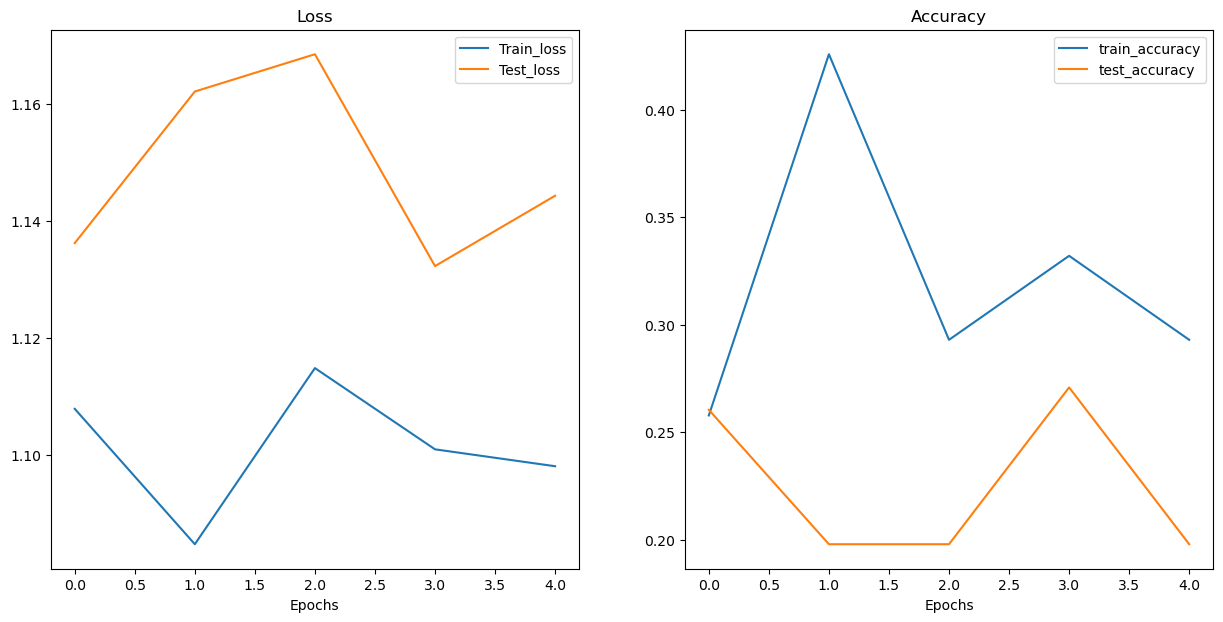

In [31]:
plot_losscurves(model_0_results)

### 8. What should an ideal loss curve look like?

https://developers.google.com/machine-learning/crash-course/overfitting/interpreting-loss-curves

A loss curve is one of the best ways to troubleshoot a model

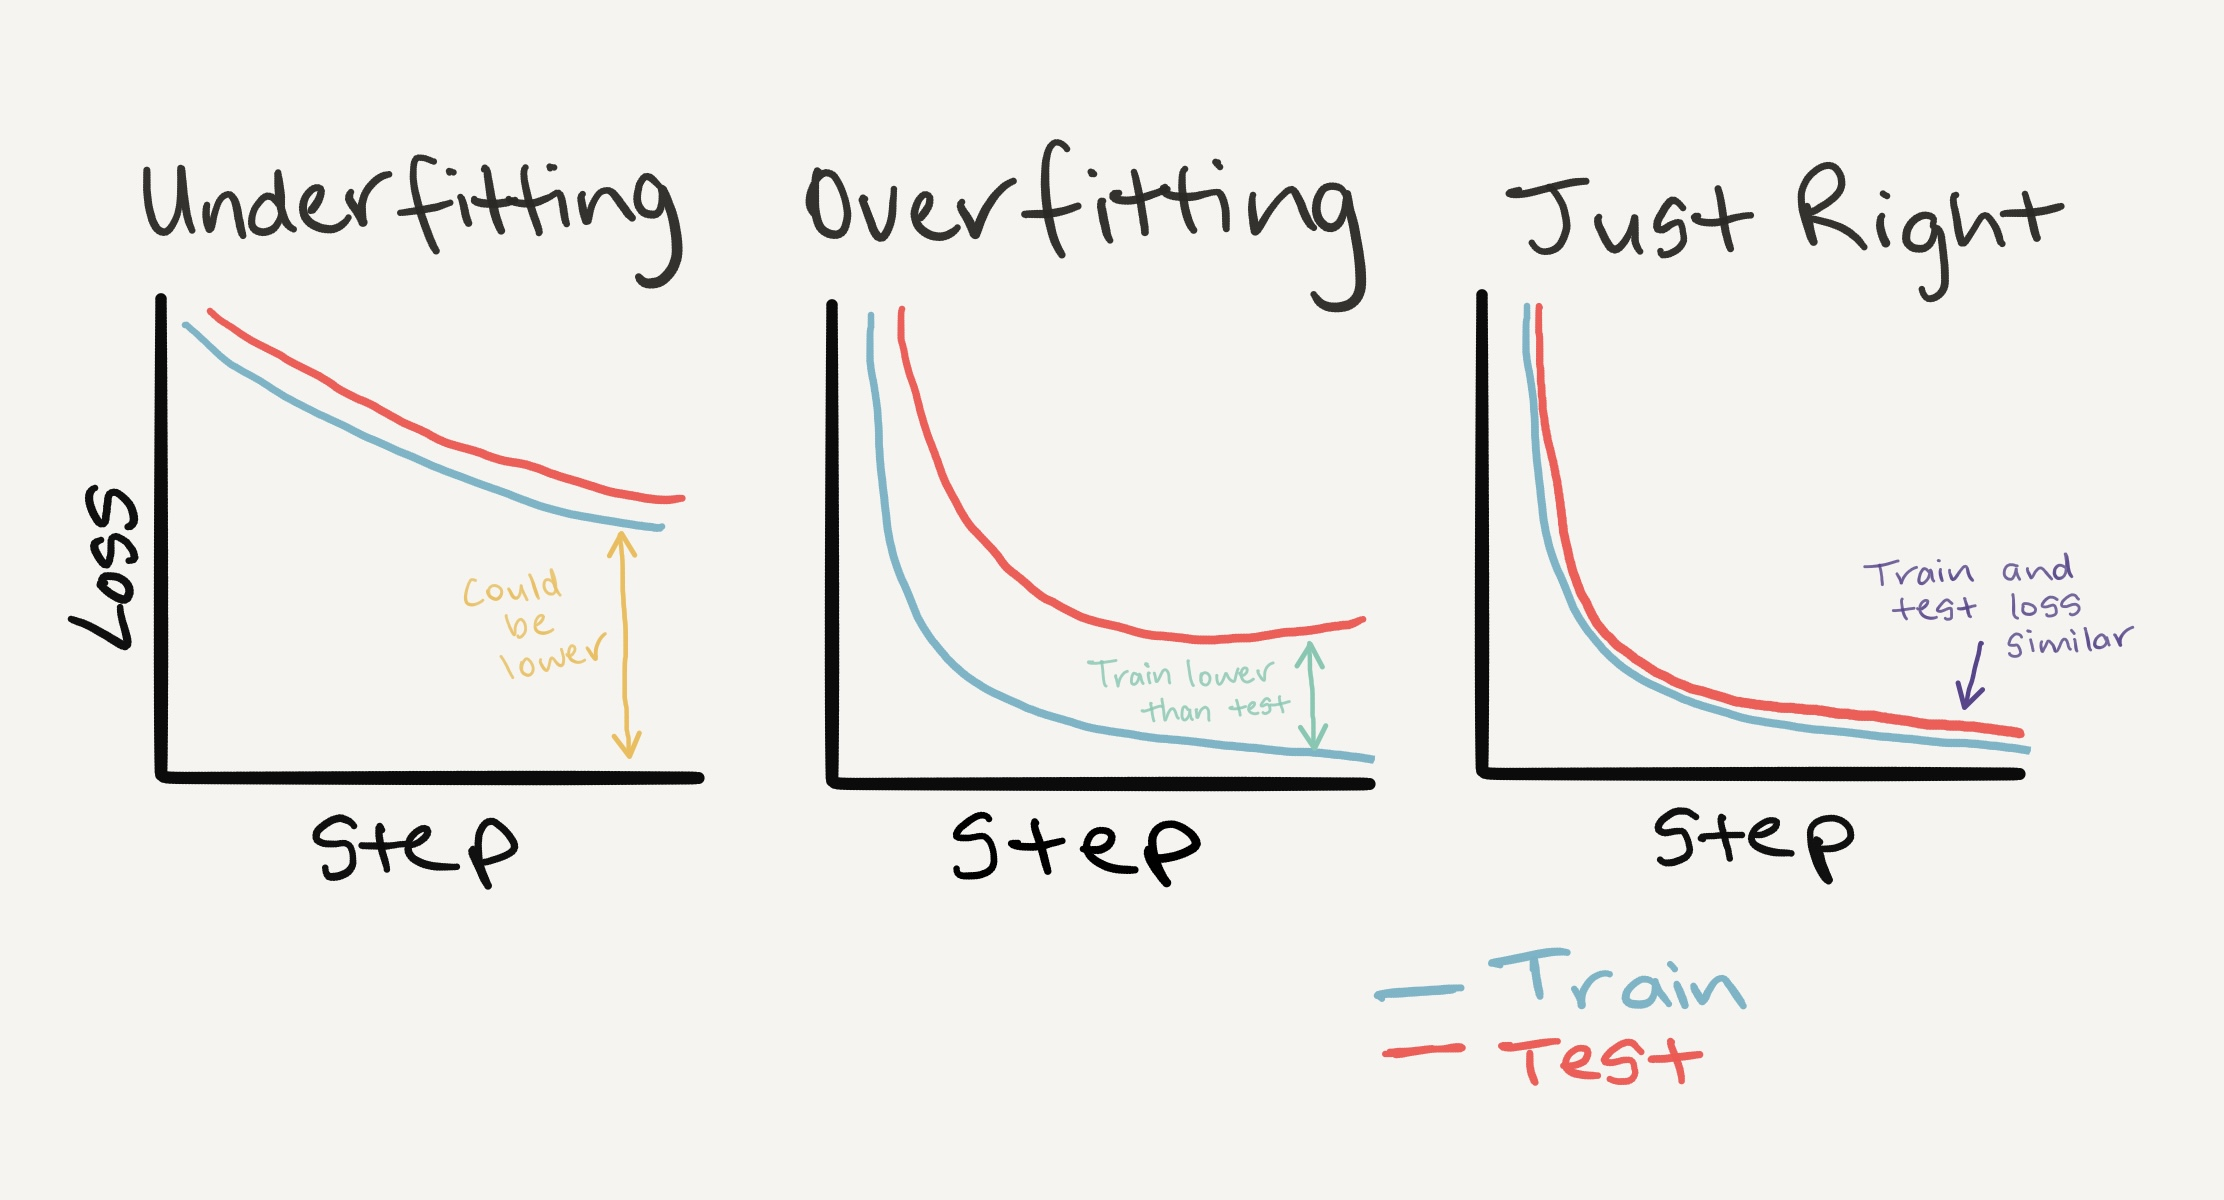

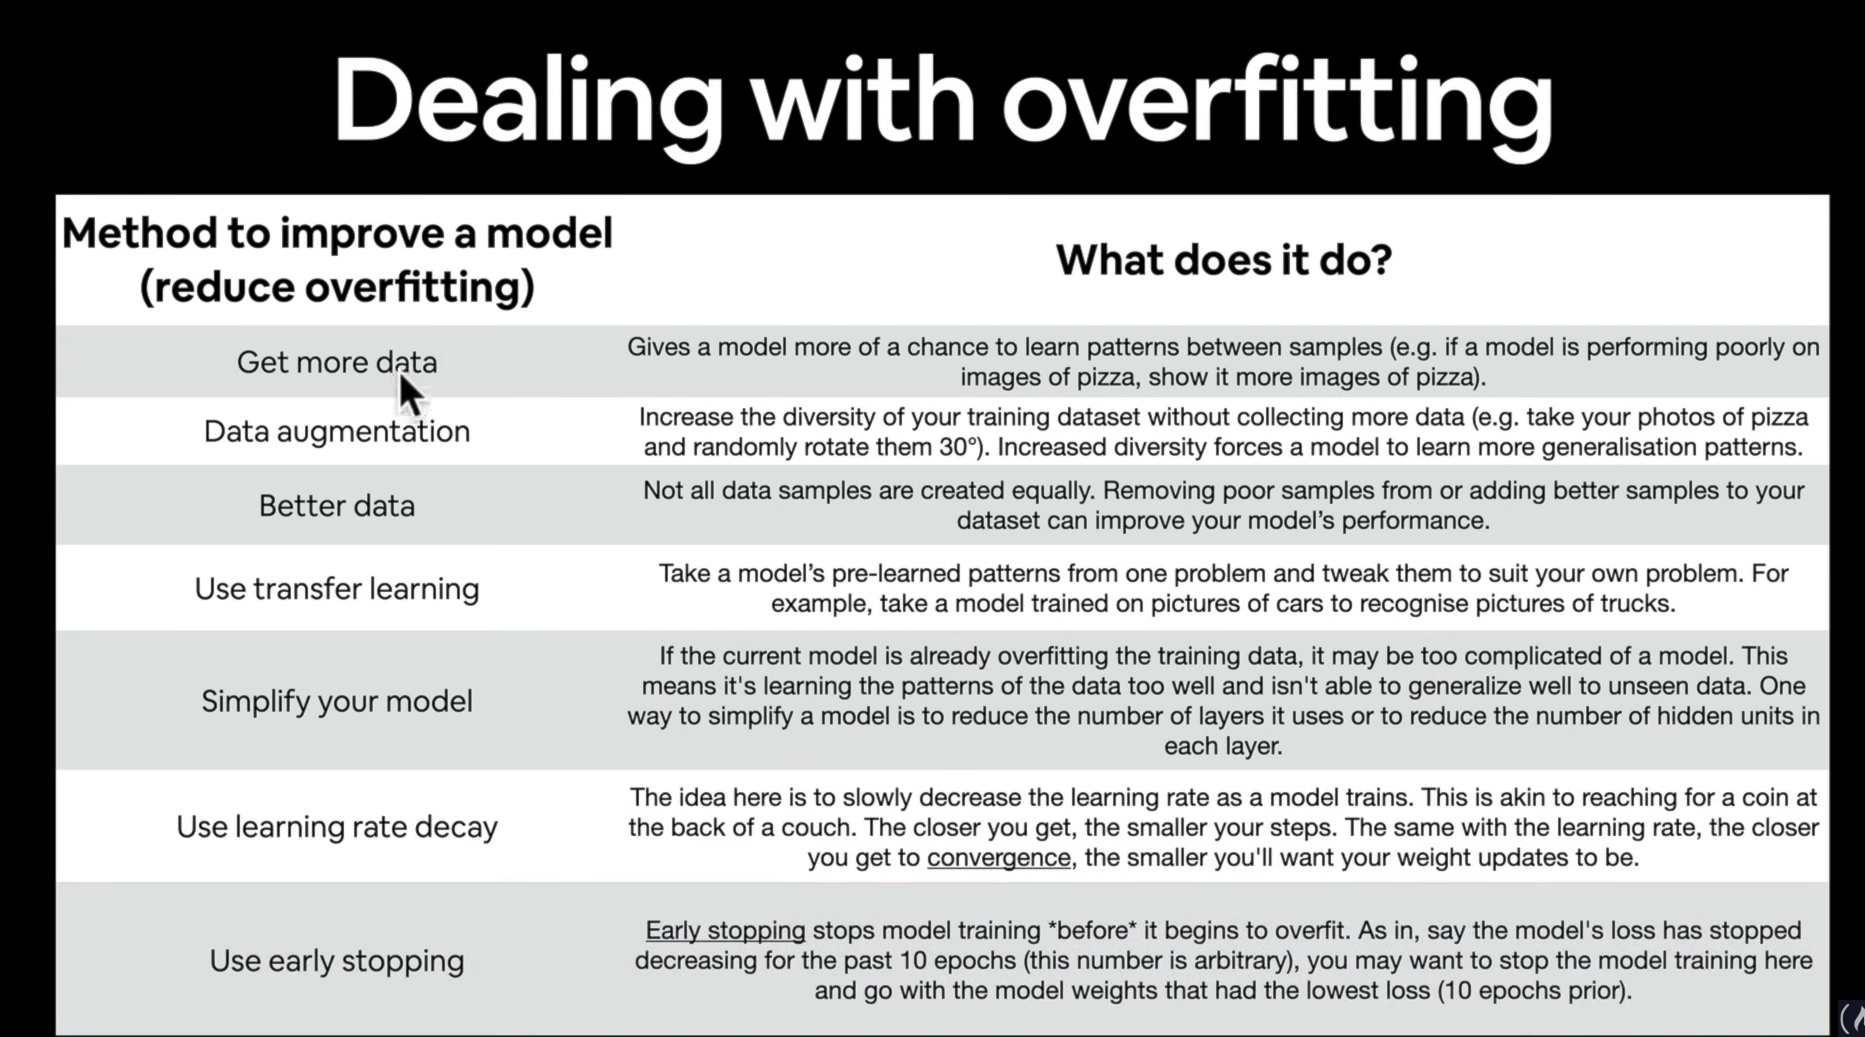

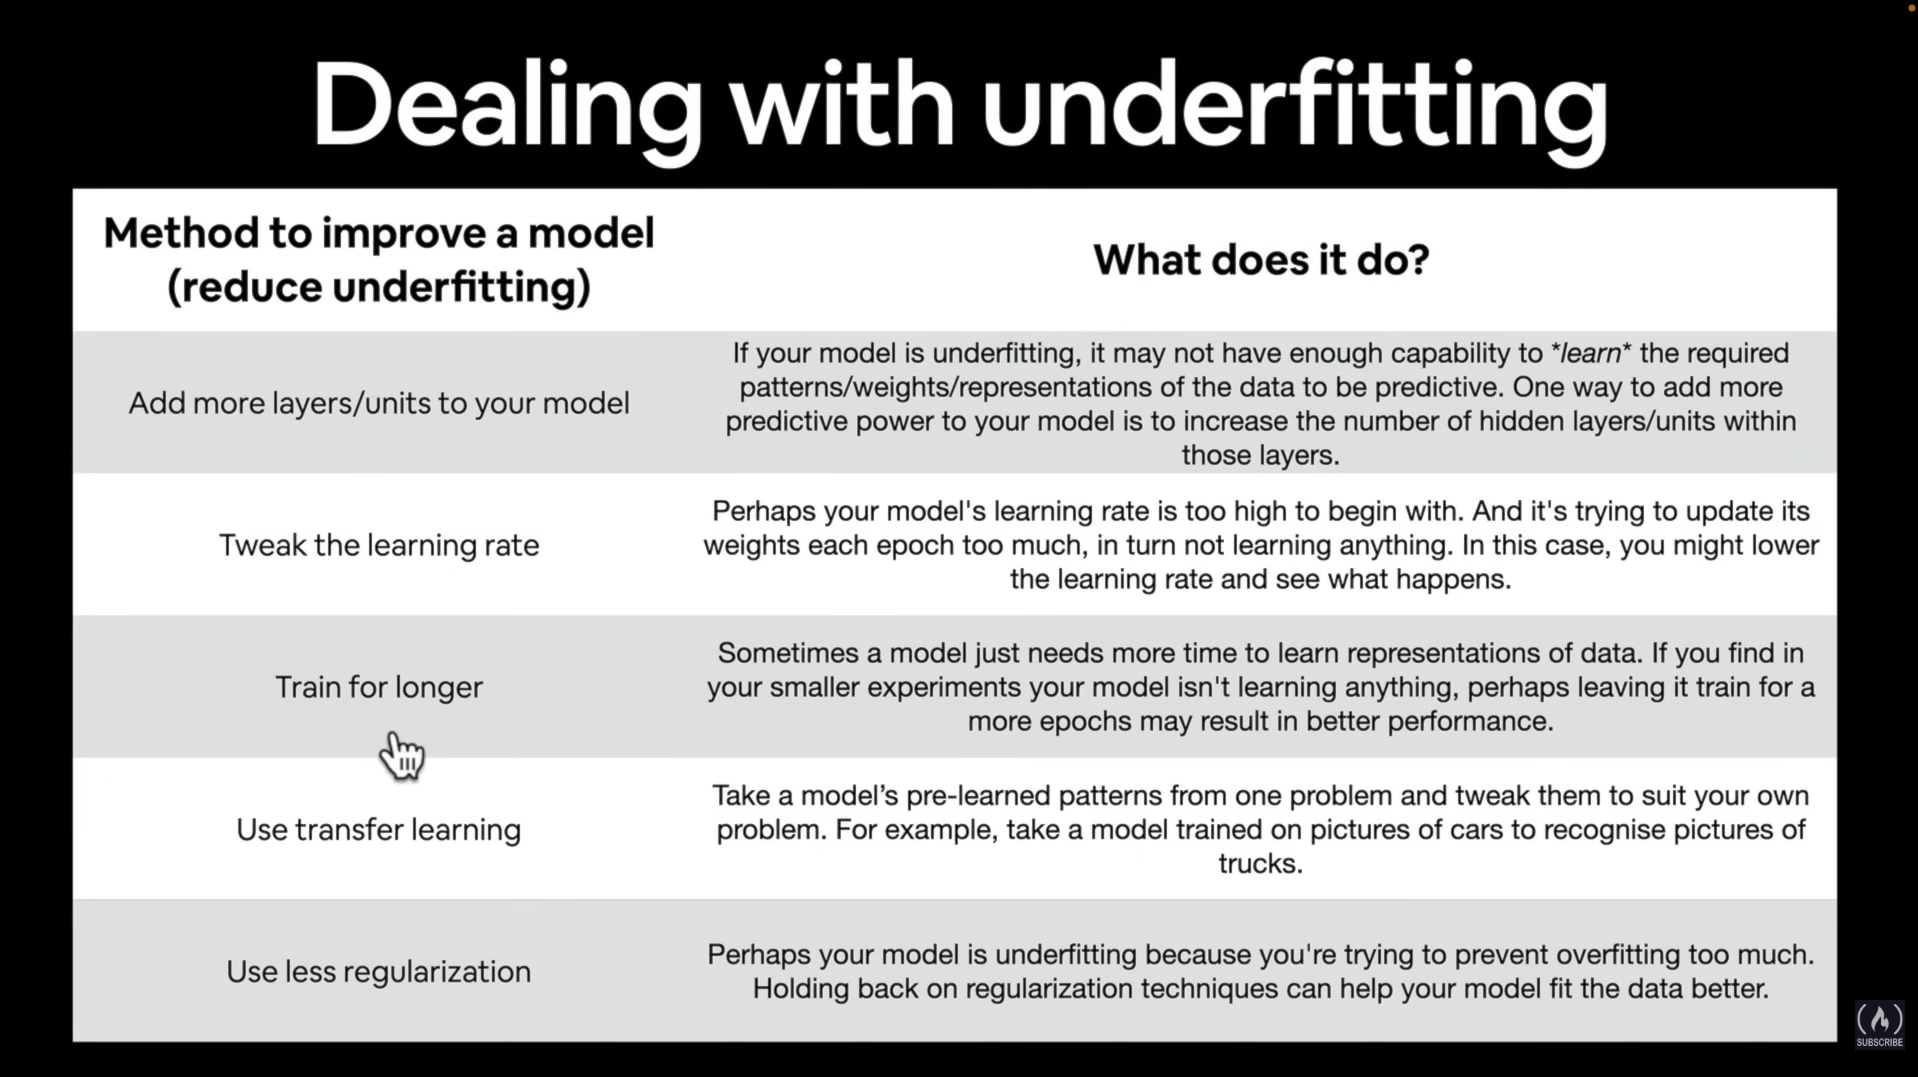

### 9. Model 1 :TinyVGG with Data augmentation

#### 9.1 Create transform with data augmentation


In [32]:
from torchvision import transforms
train_transforms_trivial = transforms.Compose([
                                            transforms.Resize(size = (64,64)),
                                            transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                            transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
                                            transforms.Resize(size = (64,64)),
                                            transforms.ToTensor()
])

### 9.2 Create and train and test `Dataset`'s and `DataLoader`'s with data augmentation

In [33]:
#Turn image folders into Datsets
from torchvision import datasets
train_data_augment = datasets.ImageFolder(root= train_dir,transform=train_transforms_trivial)
test_data_simple = datasets.ImageFolder(root = test_dir,transform=test_transform_simple)



In [34]:
train_dir

WindowsPath('data/pizza_steak_sushi/train')

In [35]:
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 0

torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_dataloader_augmented = DataLoader(dataset=train_data_augment,batch_size = BATCH_SIZE,shuffle = True,num_workers = NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset = test_data_simple,batch_size=BATCH_SIZE,shuffle = True,num_workers=NUM_WORKERS)

### 9.3 Construct and train model 1

In [36]:
torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3,hidden_units=10,output_shape=len(train_data_augment.classes)).to(device)
model_1


TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [37]:
from timeit import default_timer as timer

torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCH = 5
#Loss function is also known as criterion
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params= model_1.parameters(),lr=0.01)


#Training model_1

start_time = timer()
model_1_results = train(model=model_1,train_dataloader=train_dataloader_augmented,test_dataloader=test_dataloader_simple,
                    optimizer= optimizer,loss_fn = loss_fn,epochs = NUM_EPOCH,device=device)

end_time = timer()
print(f"Total training time for model_1 : {end_time - start_time:.3f}s")



  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 1 | Train loss : 1.1975 | Train acc : 0.3789 | Test loss: 1.1386 | Test acc: 0.3996
Epoch : 2 | Train loss : 1.1053 | Train acc : 0.4062 | Test loss: 1.1445 | Test acc: 0.3002
Epoch : 3 | Train loss : 1.1537 | Train acc : 0.3047 | Test loss: 1.1304 | Test acc: 0.3201
Epoch : 4 | Train loss : 1.1047 | Train acc : 0.3047 | Test loss: 1.0978 | Test acc: 0.3598
Epoch : 5 | Train loss : 1.0977 | Train acc : 0.4258 | Test loss: 1.0979 | Test acc: 0.3201
Total training time for model_1 : 3.372s


#### **Note : Data augmentation helps with overfitting**

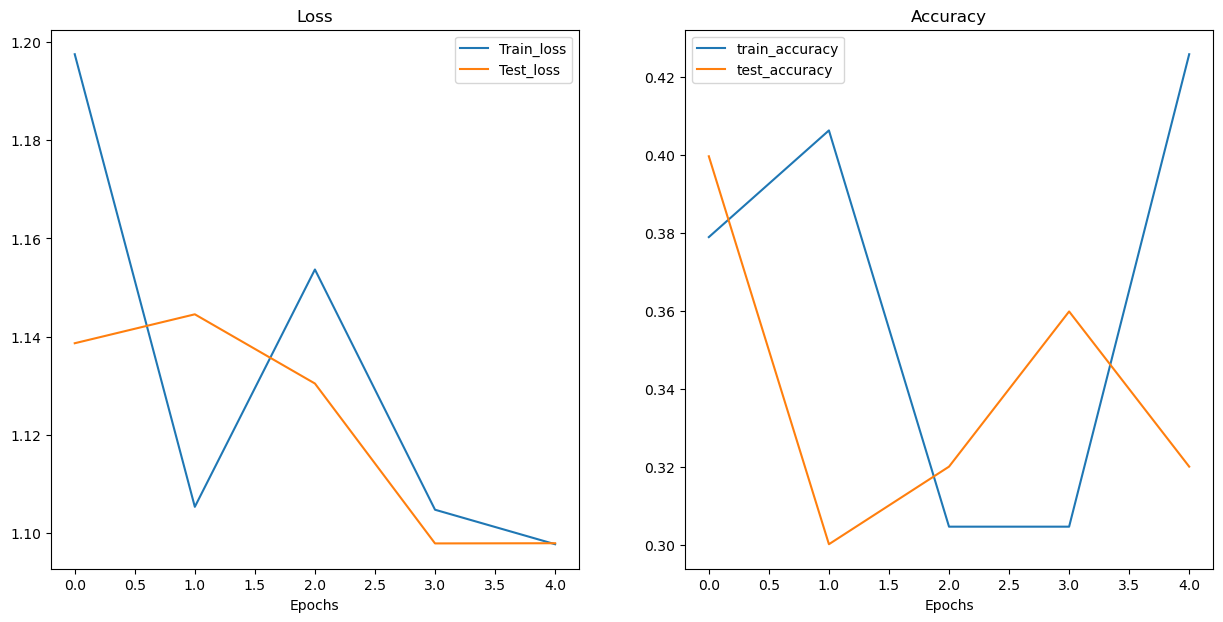

In [38]:
 #Plotting loss curves for model_1 

plot_losscurves(model_1_results)

### 10. Comparing model results

**Tools to track varibales during training:**

1.Hard coding

2.Pytorch + Tensorboard : https://docs.pytorch.org/docs/2.12/tensorboard.html

3.Weights and biases : https://wandb.ai/site/

4.Mlflow : https://mlflow.org/

In [39]:
import pandas as pd 
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,test_acc,test_loss,train_acc,train_loss
0,0.260417,1.136224,0.257812,1.107836
1,0.197917,1.162194,0.425781,1.084639
2,0.197917,1.168585,0.292969,1.114812
3,0.270833,1.132288,0.332031,1.100895
4,0.197917,1.144339,0.292969,1.098000


In [40]:
model_1_df

,test_acc,test_loss,train_acc,train_loss
0,0.399621,1.138637,0.378906,1.197549
1,0.300189,1.144534,0.406250,1.105290
2,0.320076,1.130427,0.304688,1.153669
3,0.359848,1.097833,0.304688,1.104700
4,0.320076,1.097870,0.425781,1.097669


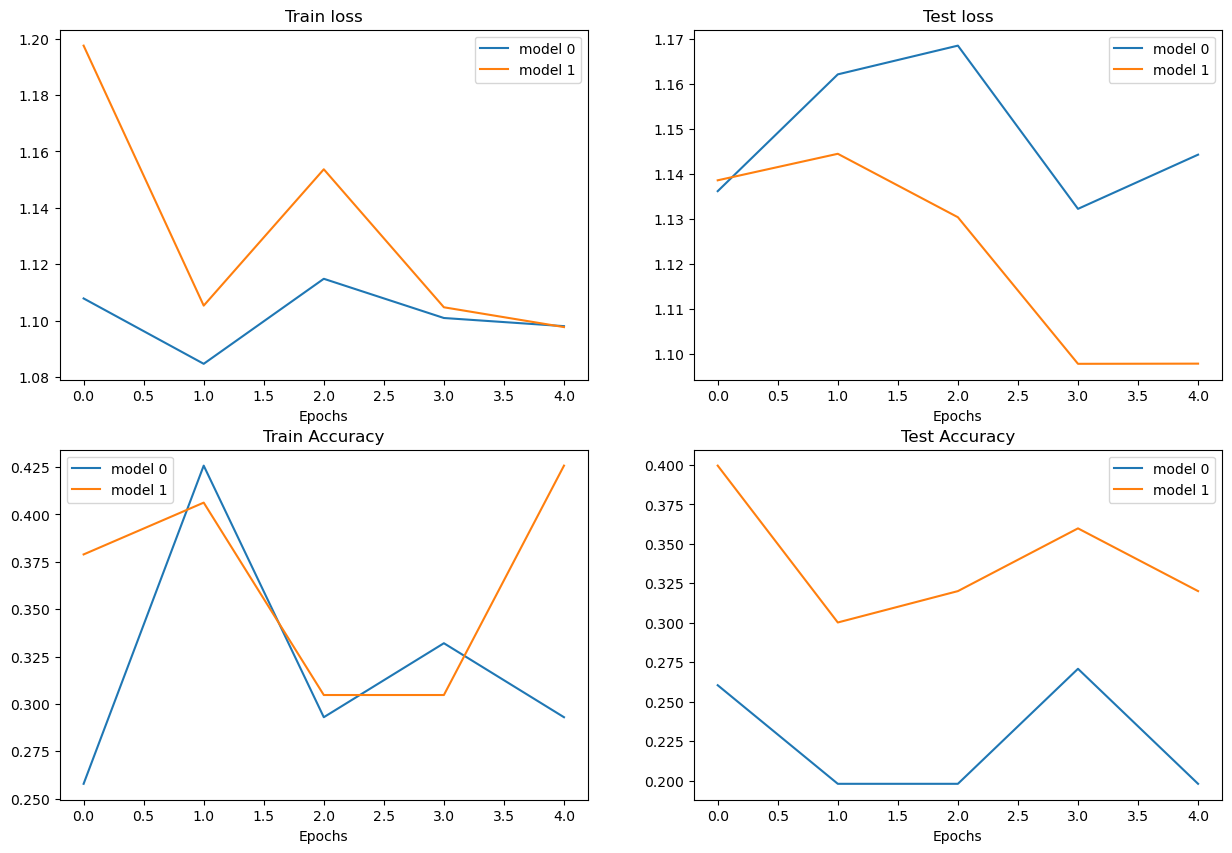

In [41]:
#Setup a plot
plt.figure(figsize=(15,10))
#Get number of epochs
epochs = range(len(model_1_df))

#Plotting the train loss
plt.subplot(2,2,1)
plt.plot(epochs,model_0_df["train_loss"],label = "model 0")
plt.plot(epochs,model_1_df["train_loss"],label = "model 1")
plt.title("Train loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,2)
plt.plot(epochs,model_0_df["test_loss"],label = "model 0")
plt.plot(epochs,model_1_df["test_loss"],label = "model 1")
plt.title("Test loss")
plt.xlabel("Epochs")
plt.legend()



plt.subplot(2,2,3)
plt.plot(epochs,model_0_df["train_acc"],label = "model 0")
plt.plot(epochs,model_1_df["train_acc"],label = "model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2,2,4)
plt.plot(epochs,model_0_df["test_acc"],label = "model 0")
plt.plot(epochs,model_1_df["test_acc"],label = "model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend()

### 11. loading a custom image with Pytorch

    

In [42]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

data\04-pizza-dad.jpeg already exists, skipping download.


In [43]:
import torchvision
import numpy as np

custom_image_unit8 = torchvision.io.read_image(custom_image_path)

custom_image_unit8_np = np.uint8(custom_image_unit8)

custom_image_unit8_np.dtype,custom_image_unit8.dtype


(dtype('uint8'), torch.uint8)

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

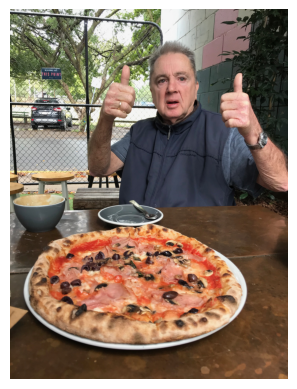

In [44]:
plt.imshow(custom_image_unit8_np.transpose(1,2,0))
plt.axis(False)

In [49]:
#Making predction on an image in uint8
custom_image_float = custom_image_unit8.type(torch.float32) / 255.0
custom_image_float = custom_image_float.to(device)
model_1.eval()
with torch.inference_mode():
    model_1(custom_image_transformed)
    #Not the right dimensions

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x256 and 2560x3)

In [48]:
#Ccreating a trasnform piepline to resize the image

from torchvision import transforms

custom_image_transform = transforms.Compose([transforms.Resize(size=(64,64))])

#Trasnforming the target image
custom_image_transformed = custom_image_transform(custom_image_float)
print(f"Original shape : {custom_image_float.shape}")
print(f"Transformed shape : {custom_image_transformed.shape}")

Original shape : torch.Size([3, 4032, 3024])
Transformed shape : torch.Size([3, 64, 64])


In [47]:
model_1.eval()
with torch.inference_mode():
    custom_img_pred = model_1(custom_image_transformed.to(device))
    #No batch size

NameError: name 'custom_image_transformed' is not defined

In [46]:
#Adding a batch size
custom_image_transformed.shape,custom_image_transformed.unsqueeze(0).shape

NameError: name 'custom_image_transformed' is not defined

In [50]:
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))
custom_image_pred

tensor([[ 0.0164, -0.0062,  0.0095]], device='cuda:0')

#### **Note: to make a preditcion on a custom image:**

1.Right Width and Height and colot dimensions (Respective of on what the model was trained on)

2.Right dimensions in this case there was no batch size so we added it 

3.Right device 

4.Right datatype i.e the image should be in the tensor format


In [51]:
#Convert logits into predcition probabilites
custom_img_pred_probs = torch.softmax(custom_image_pred,dim = 1)
custom_img_pred_probs

tensor([[0.3366, 0.3291, 0.3343]], device='cuda:0')

In [53]:
#Converting probabilites into labels
custom_img_pred_label = torch.argmax(custom_img_pred_probs,dim = 1)
custom_img_pred_label

tensor([0], device='cuda:0')

In [54]:
class_names[custom_img_pred_label]

'pizza'

### 11.3 Building a function for predictions

In [60]:
def pred_plot_img(model:torch.nn.Module,image_path:str,class_names:list[str] = None,transform = None,device = device):
    """Makes a prediction on a target image with a trained model and plots the image and the predcition"""
    #Loading an image
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    #Divide the image pixel value by 255 to get them between [0,1]
    target_image  = target_image / 255.

    #Transform the data if neccessary 
    if transform:
        target_image = transform(target_image)

    #The model should be on the same device
    model.to(device)

    #Turn the moodel to eval mode
    model.eval()
    with torch.inference_mode():
        #Add an extra dimension to the image i.e Batch_size since it is an image that is taken from outside the dataset 
        target_image = target_image.unsqueeze(0)

        #Making a prediciton with an extra dimension
        target_img_pred = model(target_image.to(device)) #Make sure the image and the model are on the same device

        #Convert logits into probabilites
        target_img_pred_probs = torch.softmax(target_img_pred,dim = 1)

        #Convert prediction probabilites 
        target_img_pred_labels = torch.argmax(target_img_pred_probs, dim = 1)

        #plot the image alongside the prediction and prediction probabilites
        #Removing the batch dimension and rearrgeing the dim to HWC
        plt.imshow(target_image.squeeze().permute(1,2,0))

        if class_names:
            title = f"Pred : {class_names[target_img_pred_labels.cpu()]} | Prob : {target_img_pred_probs.max().cpu():.3f}"
        else:
            title = f"Pred : {target_img_pred_labels} | Prob : {target_img_pred_probs.max().cpu():.3f}"

        plt.title(title)
        plt.axis(False)





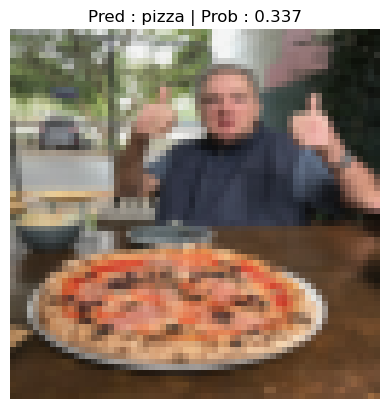

In [61]:
#Making predictions using the function
pred_plot_img(model= model_1,image_path=custom_image_path,class_names=class_names,transform=custom_image_transform,device=device)